# Retrieval, Faithfulness, and Abstention Metrics

This notebook loads evaluation outputs from:
- `retrieval_metrics/comparison.csv`
- `llm_faithfulness_metrics/comparison.csv`
- `abstention_metrics/comparison.csv`

and presents latest metric tables across retrieval, faithfulness, and abstention evaluations.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 100)

In [15]:
import csv

base = Path('.')
retrieval_csv = base / 'retrieval_metrics' / 'comparison.csv'
faith_csv = base / 'llm_faithfulness_metrics' / 'comparison.csv'
abstention_csv = base / 'abstention_metrics' / 'comparison.csv'

retrieval = pd.read_csv(retrieval_csv)
abstention = pd.read_csv(abstention_csv)

def read_mixed_width_csv(path: Path) -> pd.DataFrame:
    rows = []
    with path.open('r', encoding='utf-8', newline='') as fh:
        reader = csv.reader(fh)
        header = next(reader)

        old_answer_model_idx = header.index('answer_model') if 'answer_model' in header else len(header)

        # New schema adds retrieval_mode and dense_top_k before answer_model
        target_header = list(header)
        if 'retrieval_mode' not in target_header:
            target_header.insert(old_answer_model_idx, 'retrieval_mode')
            target_header.insert(old_answer_model_idx + 1, 'dense_top_k')

        for raw in reader:
            if not raw:
                continue
            row = list(raw)

            # Old rows (18 cols): inject missing retrieval fields at original answer_model position
            if len(row) == len(target_header) - 2:
                row = row[:old_answer_model_idx] + ['', ''] + row[old_answer_model_idx:]

            # Any other width: pad or trim defensively
            if len(row) < len(target_header):
                row = row + [''] * (len(target_header) - len(row))
            elif len(row) > len(target_header):
                row = row[:len(target_header)]

            rows.append(row)

    return pd.DataFrame(rows, columns=target_header)

faith = read_mixed_width_csv(faith_csv)

retrieval['timestamp'] = pd.to_datetime(retrieval['timestamp'])
faith['timestamp'] = pd.to_datetime(faith['timestamp'])
abstention['timestamp'] = pd.to_datetime(abstention['timestamp'])

num_cols = [
    'n_queries',
    'total_claims',
    'claim_support_rate',
    'contradicted_claim_rate',
    'not_found_claim_rate',
    'unfaithful_claim_rate',
    'query_faithfulness_rate',
    'contradiction_weighted_hallucination',
    'faithful_label_agreement',
    'unfaithful_presence_agreement',
    'max_queries',
    'dense_top_k',
]
for col in num_cols:
    if col in faith.columns:
        faith[col] = pd.to_numeric(faith[col], errors='coerce')

abstention_num_cols = [
    'n_examples', 'n_should_abstain', 'n_should_answer',
    'n_pred_abstain', 'n_pred_answer',
    'tp', 'tn', 'fp', 'fn',
    'abstention_accuracy', 'true_abstain_rate', 'false_answer_rate',
    'false_abstain_rate', 'precision_abstain', 'recall_abstain', 'f1_abstain',
]
for col in abstention_num_cols:
    if col in abstention.columns:
        abstention[col] = pd.to_numeric(abstention[col], errors='coerce')

retrieval.tail(3), faith.tail(4), abstention.tail(4)

(             timestamp                  run_name           mode  n_queries  \
 12 2026-03-18 00:29:58  baseline_300_new_metrics          dense        300   
 13 2026-03-18 00:29:58  baseline_300_new_metrics         hybrid        300   
 14 2026-03-18 00:29:58  baseline_300_new_metrics  hybrid_rerank        300   
 
     recall_at_1  recall_at_3  recall_at_5  recall_at_10       mrr  \
 12     0.203333     0.380000     0.433333      0.523333  0.303697   
 13     0.310000     0.506667     0.616667      0.743333  0.438888   
 14     0.420000     0.653333     0.726667      0.806667  0.551778   
 
     avg_hit_rank  median_hit_rank  ndcg_at_10  precision_at_5  latency_p50_ms  \
 12      3.012739              2.0    0.356267        0.086667       76.731791   
 13      3.058296              2.0    0.511173        0.123333       86.904875   
 14      2.380165              1.0    0.613549        0.145333       89.418626   
 
     latency_p95_ms     top_k  dense_pool  sparse_pool  rerank_pool  r

## 1) Retrieval (latest 300-query run) by mode

In [3]:
retr_300_all = retrieval[retrieval['n_queries'] >= 300].copy()
retr_300_all = retr_300_all.sort_values('timestamp')

# Keep latest row per mode (lets notebook auto-pick newest 300-query run)
retr_300 = retr_300_all.groupby('mode', as_index=False).tail(1).sort_values('mode')

display_cols = [
    'run_name', 'timestamp', 'mode',
    'recall_at_1', 'recall_at_3', 'recall_at_5', 'recall_at_10',
    'mrr', 'ndcg_at_10', 'precision_at_5', 'latency_p50_ms', 'latency_p95_ms',
]

retr_300[display_cols]

,run_name,timestamp,mode,recall_at_1,recall_at_3,recall_at_5,recall_at_10,mrr,ndcg_at_10,precision_at_5,latency_p50_ms,latency_p95_ms
12,baseline_300_new_metrics,2026-03-18 00:29:58,dense,0.203333,0.380000,0.433333,0.523333,0.303697,0.356267,0.086667,76.731791,82.597542
13,baseline_300_new_metrics,2026-03-18 00:29:58,hybrid,0.310000,0.506667,0.616667,0.743333,0.438888,0.511173,0.123333,86.904875,94.870125
14,baseline_300_new_metrics,2026-03-18 00:29:58,hybrid_rerank,0.420000,0.653333,0.726667,0.806667,0.551778,0.613549,0.145333,89.418626,97.414875


In [9]:
latest_run = retr_300['run_name'].iloc[0] if len(retr_300) else 'latest_300'

retrieval_table = retr_300[[
    'mode', 'recall_at_1', 'recall_at_3', 'recall_at_5', 'recall_at_10',
    'mrr', 'ndcg_at_10', 'precision_at_5', 'latency_p50_ms', 'latency_p95_ms',
]].copy()

for col in retrieval_table.columns:
    if col != 'mode':
        retrieval_table[col] = pd.to_numeric(retrieval_table[col], errors='coerce')

retrieval_table = retrieval_table.sort_values('mode').reset_index(drop=True)

print(f'Retrieval metrics table ({latest_run})')
retrieval_table.style.format({
    'recall_at_1': '{:.3f}',
    'recall_at_3': '{:.3f}',
    'recall_at_5': '{:.3f}',
    'recall_at_10': '{:.3f}',
    'mrr': '{:.3f}',
    'ndcg_at_10': '{:.3f}',
    'precision_at_5': '{:.3f}',
    'latency_p50_ms': '{:.1f}',
    'latency_p95_ms': '{:.1f}',
}).background_gradient(subset=['recall_at_10', 'mrr', 'ndcg_at_10', 'precision_at_5'], cmap='Blues')

Retrieval metrics table (baseline_300_new_metrics)


,mode,recall_at_1,recall_at_3,recall_at_5,recall_at_10,mrr,ndcg_at_10,precision_at_5,latency_p50_ms,latency_p95_ms
0,dense,0.203,0.380,0.433,0.523,0.304,0.356,0.087,76.7,82.6
1,hybrid,0.310,0.507,0.617,0.743,0.439,0.511,0.123,86.9,94.9
2,hybrid_rerank,0.420,0.653,0.727,0.807,0.552,0.614,0.145,89.4,97.4


## 2) Faithfulness comparison (external judge): hybrid_rerank vs dense retrieval

In [12]:
faith_ext = faith[faith['judge_type'] == 'external'].copy()
faith_300 = faith_ext[(faith_ext['n_queries'] >= 299) & (faith_ext['run_name'].isin(['faithfulness_baseline_300', 'faithfulness_dense_300']))].copy()

# Label retrieval mode for older rows that predate explicit retrieval_mode column
if 'retrieval_mode' not in faith_300.columns:
    faith_300['retrieval_mode'] = ''

faith_300['retrieval_mode_clean'] = faith_300['retrieval_mode'].fillna('')
faith_300.loc[faith_300['run_name'] == 'faithfulness_baseline_300', 'retrieval_mode_clean'] = faith_300.loc[faith_300['run_name'] == 'faithfulness_baseline_300', 'retrieval_mode_clean'].replace('', 'default')
faith_300.loc[faith_300['run_name'] == 'faithfulness_dense_300', 'retrieval_mode_clean'] = faith_300.loc[faith_300['run_name'] == 'faithfulness_dense_300', 'retrieval_mode_clean'].replace('', 'dense')

cols = ['run_name', 'retrieval_mode_clean', 'n_queries', 'claim_support_rate', 'unfaithful_claim_rate', 'contradicted_claim_rate', 'not_found_claim_rate', 'query_faithfulness_rate', 'contradiction_weighted_hallucination']
faith_300[cols].sort_values('retrieval_mode_clean')

,run_name,retrieval_mode_clean,n_queries,claim_support_rate,unfaithful_claim_rate,contradicted_claim_rate,not_found_claim_rate,query_faithfulness_rate,contradiction_weighted_hallucination
2,faithfulness_baseline_300,default,299,0.873309,0.038130,0.011070,0.027060,0.729097,0.049200
4,faithfulness_dense_300,dense,299,0.854981,0.021438,0.003783,0.017654,0.725753,0.025221


In [13]:
faith_table = faith_300[[
    'run_name', 'retrieval_mode_clean', 'n_queries',
    'query_faithfulness_rate', 'claim_support_rate',
    'unfaithful_claim_rate', 'contradicted_claim_rate', 'not_found_claim_rate',
    'contradiction_weighted_hallucination',
]].copy()

faith_table = faith_table.rename(columns={'retrieval_mode_clean': 'mode'})
faith_table = faith_table.sort_values('mode').reset_index(drop=True)

for col in [
    'query_faithfulness_rate', 'claim_support_rate',
    'unfaithful_claim_rate', 'contradicted_claim_rate', 'not_found_claim_rate',
    'contradiction_weighted_hallucination',
    'n_queries',
]:
    if col in faith_table.columns:
        faith_table[col] = pd.to_numeric(faith_table[col], errors='coerce')

print('Faithfulness metrics table (external judge)')
faith_table.style.format({
    'query_faithfulness_rate': '{:.3f}',
    'claim_support_rate': '{:.3f}',
    'unfaithful_claim_rate': '{:.3f}',
    'contradicted_claim_rate': '{:.3f}',
    'not_found_claim_rate': '{:.3f}',
    'contradiction_weighted_hallucination': '{:.3f}',
    'n_queries': '{:.0f}',
}).background_gradient(subset=['query_faithfulness_rate', 'claim_support_rate'], cmap='Greens').background_gradient(subset=['unfaithful_claim_rate', 'contradicted_claim_rate', 'not_found_claim_rate', 'contradiction_weighted_hallucination'], cmap='Reds_r')

Faithfulness metrics table (external judge)


,run_name,mode,n_queries,query_faithfulness_rate,claim_support_rate,unfaithful_claim_rate,contradicted_claim_rate,not_found_claim_rate,contradiction_weighted_hallucination
0,faithfulness_baseline_300,default,299,0.729,0.873,0.038,0.011,0.027,0.049
1,faithfulness_dense_300,dense,299,0.726,0.855,0.021,0.004,0.018,0.025


## 3) Judge sensitivity view (external vs Qwen)

In [9]:
faith_runs = faith[(faith['run_name'].isin(['faithfulness_baseline_300', 'faithfulness_dense_300'])) & (faith['n_queries'] >= 299)].copy()

if 'retrieval_mode' not in faith_runs.columns:
    faith_runs['retrieval_mode'] = ''

faith_runs['retrieval_mode_clean'] = faith_runs['retrieval_mode'].fillna('')
faith_runs.loc[faith_runs['run_name'] == 'faithfulness_baseline_300', 'retrieval_mode_clean'] = faith_runs.loc[faith_runs['run_name'] == 'faithfulness_baseline_300', 'retrieval_mode_clean'].replace('', 'default')
faith_runs.loc[faith_runs['run_name'] == 'faithfulness_dense_300', 'retrieval_mode_clean'] = faith_runs.loc[faith_runs['run_name'] == 'faithfulness_dense_300', 'retrieval_mode_clean'].replace('', 'dense')

judge_view = faith_runs[['run_name', 'retrieval_mode_clean', 'judge_type', 'query_faithfulness_rate', 'unfaithful_claim_rate', 'contradicted_claim_rate']]
judge_view.sort_values(['retrieval_mode_clean', 'judge_type'])

,run_name,retrieval_mode_clean,judge_type,query_faithfulness_rate,unfaithful_claim_rate,contradicted_claim_rate
2,faithfulness_baseline_300,default,external,0.729097,0.038130,0.011070
3,faithfulness_baseline_300,default,qwen,0.812709,0.050969,0.001436
4,faithfulness_dense_300,dense,external,0.725753,0.021438,0.003783
5,faithfulness_dense_300,dense,qwen,0.812709,0.052484,0.003499


In [10]:
pivot = judge_view.pivot_table(index=['retrieval_mode_clean', 'judge_type'], values=['query_faithfulness_rate', 'unfaithful_claim_rate'])
pivot

query_faithfulness_rate  \
retrieval_mode_clean judge_type                            
default              external                   0.729097   
                     qwen                       0.812709   
dense                external                   0.725753   
                     qwen                       0.812709   

                                 unfaithful_claim_rate  
retrieval_mode_clean judge_type                         
default              external                 0.038130  
                     qwen                     0.050969  
dense                external                 0.021438  
                     qwen                     0.052484

In [ ]:
# 4) Latest abstention run summary (overall + key slices)
abstention_latest_run = abstention.sort_values('timestamp')['run_name'].iloc[-1]
abstention_latest = abstention[abstention['run_name'] == abstention_latest_run].copy()

abstention_overall = abstention_latest[abstention_latest['segment_type'] == 'overall'][[
    'run_name', 'timestamp', 'prediction_mode', 'model',
    'n_examples', 'abstention_accuracy', 'true_abstain_rate',
    'false_answer_rate', 'false_abstain_rate', 'precision_abstain', 'recall_abstain', 'f1_abstain',
]].copy()

abstention_slice = abstention_latest[abstention_latest['segment_type'] == 'slice'][[
    'segment_value', 'n_examples', 'abstention_accuracy', 'true_abstain_rate',
    'false_answer_rate', 'false_abstain_rate', 'precision_abstain', 'recall_abstain', 'f1_abstain',
]].copy()

print(f'Latest abstention run: {abstention_latest_run}')
display(abstention_overall)
display(abstention_slice.sort_values('segment_value').reset_index(drop=True))

# 5) Final summary: retrieval + generation + end-to-end metrics side-by-side
retr_latest = (
    retrieval[retrieval['n_queries'] >= 300]
    .sort_values('timestamp')
    .groupby('mode', as_index=False)
    .tail(1)
    .copy()
)

retr_view = retr_latest[[
    'mode', 'run_name', 'timestamp',
    'recall_at_10', 'ndcg_at_10', 'precision_at_5', 'latency_p95_ms',
]].rename(columns={
    'run_name': 'retrieval_run_name',
    'timestamp': 'retrieval_timestamp',
    'latency_p95_ms': 'retrieval_latency_p95_ms',
})

faith_ext = faith[faith['judge_type'] == 'external'].copy()
if 'retrieval_mode' not in faith_ext.columns:
    faith_ext['retrieval_mode'] = ''

faith_ext['retrieval_mode_clean'] = faith_ext['retrieval_mode'].fillna('')
faith_ext.loc[faith_ext['run_name'] == 'faithfulness_baseline_300', 'retrieval_mode_clean'] = (
    faith_ext.loc[faith_ext['run_name'] == 'faithfulness_baseline_300', 'retrieval_mode_clean'].replace('', 'default')
)
faith_ext.loc[faith_ext['run_name'] == 'faithfulness_dense_300', 'retrieval_mode_clean'] = (
    faith_ext.loc[faith_ext['run_name'] == 'faithfulness_dense_300', 'retrieval_mode_clean'].replace('', 'dense')
)

# Map faithfulness retrieval labels to retrieval benchmark mode names
faith_ext['mode'] = faith_ext['retrieval_mode_clean'].map({
    'default': 'hybrid_rerank',
    'dense': 'dense',
})

gen_cols = [
    'query_faithfulness_rate',
    'answer_relevance',
    'completeness',
    'conciseness',
    'answer_correctness_token_f1',
    'answer_correctness_exact_match_rate',
    'latency_total_p95_ms',
    'answer_tokens_per_retrieved_token',
]
for col in gen_cols:
    if col in faith_ext.columns:
        faith_ext[col] = pd.to_numeric(faith_ext[col], errors='coerce')

metric_cols = [c for c in gen_cols if c in faith_ext.columns]
if metric_cols:
    faith_ext['_has_new_metrics'] = faith_ext[metric_cols].notna().any(axis=1).astype(int)
else:
    faith_ext['_has_new_metrics'] = 0

faith_latest = (
    faith_ext.dropna(subset=['mode'])
    .sort_values(['mode', '_has_new_metrics', 'timestamp'])
    .drop_duplicates(subset=['mode'], keep='last')
    [['mode', 'run_name', 'timestamp'] + metric_cols]
    .rename(columns={
        'run_name': 'faithfulness_run_name',
        'timestamp': 'faithfulness_timestamp',
    })
)

summary_side_by_side = retr_view.merge(faith_latest, on='mode', how='left')
summary_side_by_side = summary_side_by_side.sort_values('mode').reset_index(drop=True)

summary_side_by_side

,mode,retrieval_run_name,retrieval_timestamp,recall_at_10,ndcg_at_10,precision_at_5,retrieval_latency_p95_ms,faithfulness_run_name,faithfulness_timestamp,query_faithfulness_rate,answer_relevance,completeness,conciseness,answer_correctness_token_f1,answer_correctness_exact_match_rate,latency_total_p95_ms,answer_tokens_per_retrieved_token
0,dense,baseline_300_new_metrics,2026-03-18 00:29:58,0.523333,0.356267,0.086667,82.597542,faithfulness_dense_300,2026-03-15 03:45:43,0.725753,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,hybrid,baseline_300_new_metrics,2026-03-18 00:29:58,0.743333,0.511173,0.123333,94.870125,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,hybrid_rerank,baseline_300_new_metrics,2026-03-18 00:29:58,0.806667,0.613549,0.145333,97.414875,faithfulness_baseline_300_new_metrics,2026-03-21 02:26:01,0.755853,0.882586,0.625118,0.079699,0.088491,0.0,78362.652375,0.269913


In [16]:
# 5) Tabular visualization: retrieval + generation + end-to-end summary
table_cols = [
    'mode',
    'recall_at_10', 'ndcg_at_10', 'precision_at_5', 'retrieval_latency_p95_ms',
    'query_faithfulness_rate',
    'answer_relevance', 'completeness', 'conciseness',
    'answer_correctness_token_f1', 'answer_correctness_exact_match_rate',
    'latency_total_p95_ms', 'answer_tokens_per_retrieved_token',
]

present_cols = [c for c in table_cols if c in summary_side_by_side.columns]
summary_table = summary_side_by_side[present_cols].copy()

for col in summary_table.columns:
    if col != 'mode':
        summary_table[col] = pd.to_numeric(summary_table[col], errors='coerce')

summary_table = summary_table.sort_values('mode').reset_index(drop=True)

style_formats = {
    'recall_at_10': '{:.3f}',
    'ndcg_at_10': '{:.3f}',
    'precision_at_5': '{:.3f}',
    'retrieval_latency_p95_ms': '{:.1f}',
    'query_faithfulness_rate': '{:.3f}',
    'answer_relevance': '{:.3f}',
    'completeness': '{:.3f}',
    'conciseness': '{:.3f}',
    'answer_correctness_token_f1': '{:.3f}',
    'answer_correctness_exact_match_rate': '{:.3f}',
    'latency_total_p95_ms': '{:.1f}',
    'answer_tokens_per_retrieved_token': '{:.3f}',
}
style_formats = {k: v for k, v in style_formats.items() if k in summary_table.columns}

high_good_cols = [c for c in ['recall_at_10', 'ndcg_at_10', 'precision_at_5', 'query_faithfulness_rate', 'answer_relevance', 'completeness', 'conciseness', 'answer_correctness_token_f1', 'answer_correctness_exact_match_rate'] if c in summary_table.columns]
low_good_cols = [c for c in ['retrieval_latency_p95_ms', 'latency_total_p95_ms', 'answer_tokens_per_retrieved_token'] if c in summary_table.columns]

styled = summary_table.style.format(style_formats)
if high_good_cols:
    styled = styled.background_gradient(subset=high_good_cols, cmap='Blues')
if low_good_cols:
    styled = styled.background_gradient(subset=low_good_cols, cmap='Reds_r')

print('Latest metrics from CSV files (tabular view)')
styled

Latest metrics from CSV files (tabular view)


,mode,recall_at_10,ndcg_at_10,precision_at_5,retrieval_latency_p95_ms,query_faithfulness_rate,answer_relevance,completeness,conciseness,answer_correctness_token_f1,answer_correctness_exact_match_rate,latency_total_p95_ms,answer_tokens_per_retrieved_token
0,dense,0.523,0.356,0.087,82.6,0.726,nan,nan,nan,nan,nan,nan,nan
1,hybrid,0.743,0.511,0.123,94.9,nan,nan,nan,nan,nan,nan,nan,nan
2,hybrid_rerank,0.807,0.614,0.145,97.4,0.756,0.883,0.625,0.080,0.088,0.000,78362.7,0.270


=== Abstention summary (timestamp-filtered, non-smoke, exclude true abstain-everything runs) ===
Rows after filters: 5 | Unique run_names: 5



,run_name,model,n_examples,f1_abstain,abstention_accuracy,true_abstain_rate,false_answer_rate,false_abstain_rate
rank,,,,,,,,
1,llama31_8b_instruct,meta-llama/Llama-3.1-8B-Instruct,900,0.703158,0.843333,0.735683,0.264317,0.120357
2,abstention_BioMistral_endpoint_non_quantised,dizza01/BioMistral-7B-DARE,900,0.644845,0.758889,0.867841,0.132159,0.277860
3,abstention_baseline,Qwen/Qwen2.5-72B-Instruct,900,0.624826,0.701111,0.986784,0.013216,0.395245
4,qwen25_7b_instruct,Qwen/Qwen2.5-7B-Instruct,900,0.592689,0.653333,1.000000,0.000000,0.463596
5,abstention_qwen7B,Qwen/Qwen2.5-7B-Instruct,900,0.591917,0.652222,1.000000,0.000000,0.465082


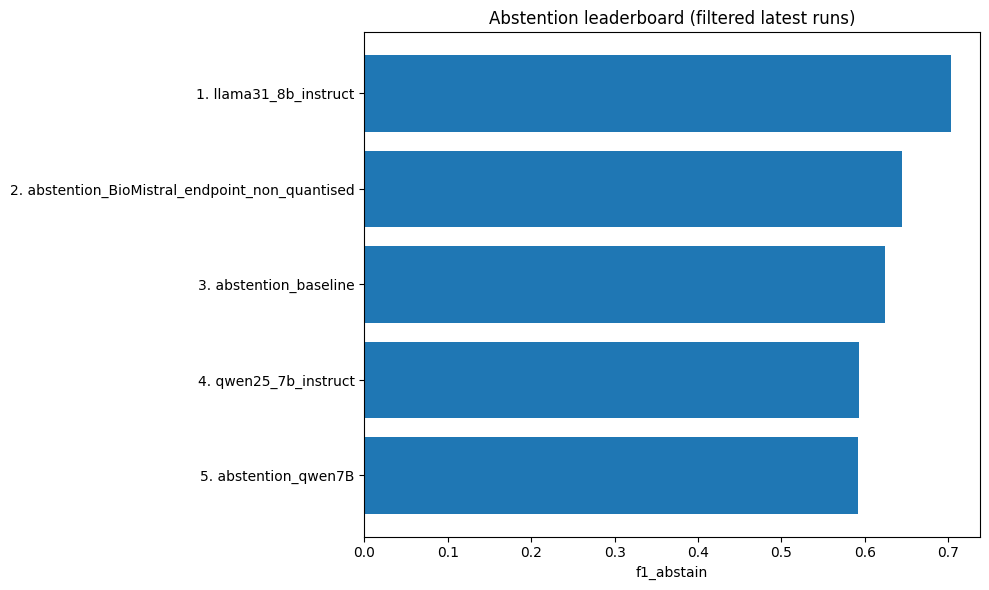

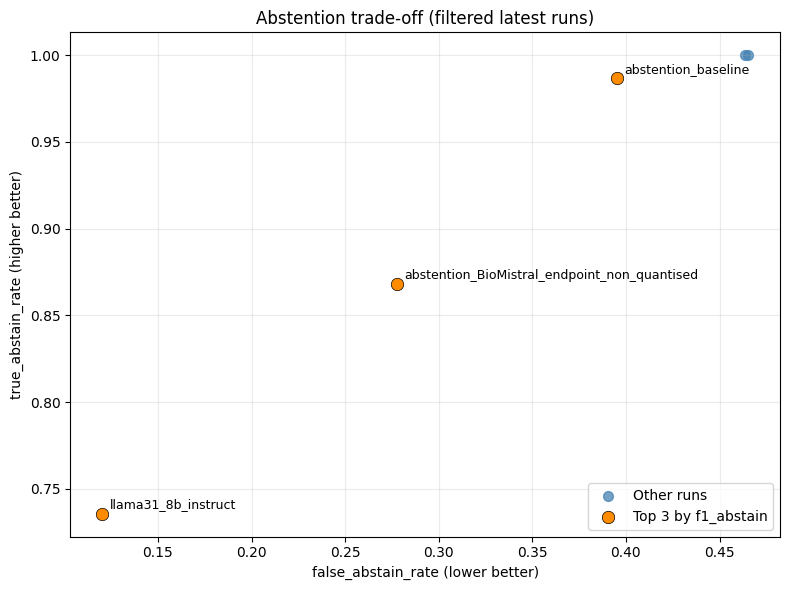

In [48]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# Abstention-only summary filters requested
MIN_TIMESTAMP = pd.Timestamp("2026-03-23T10:34:48")
TOP_N = 10

results_dir = Path.cwd()
abstention_csv = results_dir / "abstention_metrics" / "comparison.csv"

if not abstention_csv.exists():
    raise FileNotFoundError(f"Missing CSV: {abstention_csv}")

abst = pd.read_csv(abstention_csv)
abst.columns = [c.strip() for c in abst.columns]
abst["timestamp"] = pd.to_datetime(abst["timestamp"], errors="coerce")

# Keep only overall benchmark rows
abst = abst[
    (abst["segment_type"].astype(str).str.strip() == "overall")
    & (abst["segment_value"].astype(str).str.strip() == "all")
].copy()

# Apply timestamp filter
abst = abst[abst["timestamp"] >= MIN_TIMESTAMP].copy()

# Exclude smoke test runs by run_name
abst = abst[~abst["run_name"].astype(str).str.contains("smoke", case=False, na=False)].copy()

for c in [
    "n_examples",
    "n_pred_answer",
    "f1_abstain",
    "abstention_accuracy",
    "false_answer_rate",
    "true_abstain_rate",
    "false_abstain_rate",
]:
    if c in abst.columns:
        abst[c] = pd.to_numeric(abst[c], errors="coerce")

# Remove only true abstain-everything runs (all answerable items abstained)
if {"false_abstain_rate", "n_pred_answer"}.issubset(abst.columns):
    abst = abst[(abst["false_abstain_rate"] < 1.0) & (abst["n_pred_answer"] > 0)].copy()
elif "false_abstain_rate" in abst.columns:
    abst = abst[abst["false_abstain_rate"] < 1.0].copy()
elif "n_pred_answer" in abst.columns:
    abst = abst[abst["n_pred_answer"] > 0].copy()

# Keep the latest record per run_name (if duplicates exist)
abst_latest = (
    abst.sort_values("timestamp")
    .groupby("run_name", as_index=False)
    .tail(1)
    .sort_values("f1_abstain", ascending=False)
)

abst_board = abst_latest.head(TOP_N)

print("=== Abstention summary (timestamp-filtered, non-smoke, exclude true abstain-everything runs) ===")
print(f"Rows after filters: {len(abst)} | Unique run_names: {abst['run_name'].nunique()}\n")

ranked_table = abst_board[
    [
        "run_name",
        "model",
        "n_examples",
        "f1_abstain",
        "abstention_accuracy",
        "true_abstain_rate",
        "false_answer_rate",
        "false_abstain_rate",
    ]
].copy()
ranked_table.insert(0, "rank", range(1, len(ranked_table) + 1))
ranked_table = ranked_table.set_index("rank")

display(ranked_table)

# Plot 1: leaderboard with rank-prefixed labels
rank_map = {row.run_name: idx + 1 for idx, row in abst_board.reset_index(drop=True).iterrows()}
plot_df = abst_board.sort_values("f1_abstain", ascending=True).copy()
plot_df["ranked_label"] = plot_df["run_name"].map(lambda name: f"{rank_map.get(name, '?')}. {name}")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["ranked_label"], plot_df["f1_abstain"])
plt.xlabel("f1_abstain")
plt.title("Abstention leaderboard (filtered latest runs)")
plt.tight_layout()
plt.show()

# Plot 2: trade-off with reduced label clutter
trade_df = abst_board.copy()
top3_idx = trade_df["f1_abstain"].nlargest(3).index
trade_df["is_top3"] = trade_df.index.isin(top3_idx)

others = trade_df[~trade_df["is_top3"]]
top3 = trade_df[trade_df["is_top3"]]

plt.figure(figsize=(8, 6))
plt.scatter(
    others["false_abstain_rate"],
    others["true_abstain_rate"],
    color="steelblue",
    alpha=0.75,
    s=50,
    label="Other runs",
)
plt.scatter(
    top3["false_abstain_rate"],
    top3["true_abstain_rate"],
    color="darkorange",
    edgecolor="black",
    linewidth=0.5,
    s=80,
    label="Top 3 by f1_abstain",
)

for _, row in top3.iterrows():
    plt.annotate(
        str(row["run_name"]),
        (row["false_abstain_rate"], row["true_abstain_rate"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=9,
    )

plt.xlabel("false_abstain_rate (lower better)")
plt.ylabel("true_abstain_rate (higher better)")
plt.title("Abstention trade-off (filtered latest runs)")
plt.legend(loc="lower right", frameon=True)
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

=== Faithfulness summary (external judge, smoke excluded, n_queries >= 299, token_f1 present) ===
Rows after filters: 17 | Unique run_names: 16



,run_name,timestamp,answer_model,n_queries,query_faithfulness_rate,unfaithful_claim_rate,answer_correctness_token_f1,rank_score
rank,,,,,,,,
1,faithfulness_qwen72b_instruct,2026-04-14 13:37:14,Qwen/Qwen2.5-72B-Instruct,298,0.755034,0.019531,0.088460,0.887642
2,faithfulness_biomistral-7b-dare_endpoint_test,2026-04-20 10:22:45,dizza01/BioMistral-7B-DARE,105,0.723810,0.000000,0.000000,0.886275
3,faithfulness_Llama-3.1-70B-Instruct,2026-04-27 19:34:01,meta-llama/Llama-3.1-70B-Instruct,104,0.798077,0.055133,0.095539,0.884424
4,faithfulness_biomistral-7b-dare_endpoint,2026-04-14 07:59:33,dizza01/BioMistral-7B-DARE,300,0.710000,0.003711,0.005213,0.878406
5,faithfulness_qwen25_7b_instruct,2026-03-31 13:25:48,Qwen/Qwen2.5-7B-Instruct,300,0.743333,0.034982,0.097853,0.873736
6,faithfulness_Llama-3.1-8B-Instruct,2026-04-28 11:29:12,meta-llama/Llama-3.1-8B-Instruct,103,0.786408,0.070330,0.101877,0.870680
7,faithfulness_llama31_8b_instruct,2026-03-29 12:55:59,meta-llama/Llama-3.1-8B-Instruct,299,0.769231,0.059432,0.110677,0.870018
8,faithfulness_baseline,2026-04-19 19:45:32,Qwen/Qwen2.5-7B-Instruct,105,0.723810,0.036364,0.088352,0.864884
9,faithfulness_qwen7B-Instruct,2026-04-27 20:41:59,Qwen/Qwen2.5-7B-Instruct,105,0.685714,0.056940,0.092505,0.837094


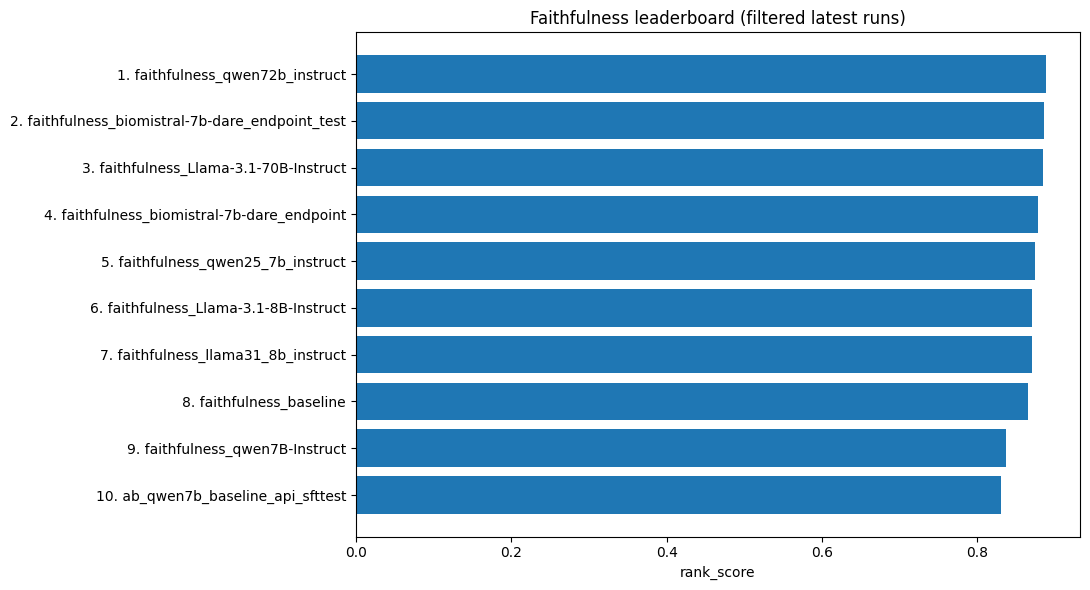

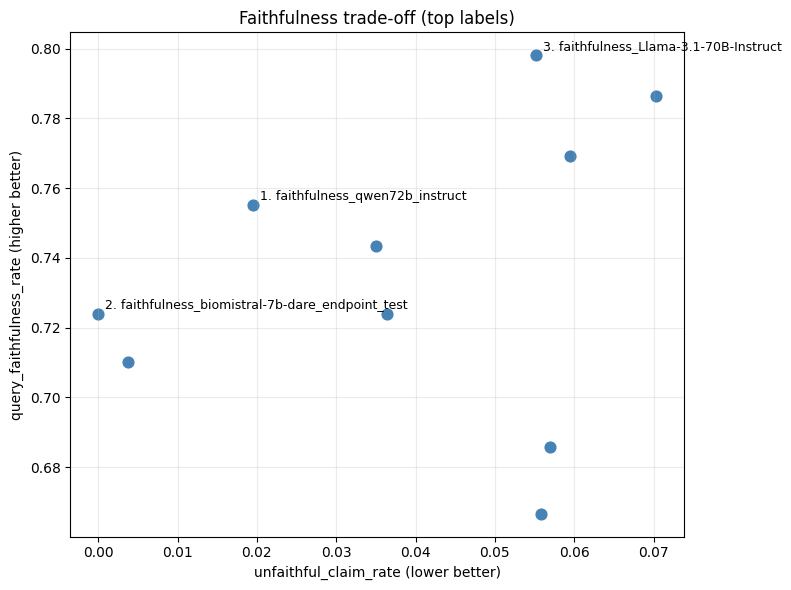

In [ ]:
from pathlib import Path
import csv
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

TOP_N = 10

results_dir = Path.cwd()
faith_csv = results_dir / "llm_faithfulness_metrics" / "comparison.csv"

if not faith_csv.exists():
    raise FileNotFoundError(f"Missing CSV: {faith_csv}")

# Handle mixed-width historical rows by inserting retrieval fields for older schema
rows = []
with faith_csv.open("r", encoding="utf-8", newline="") as fh:
    reader = csv.reader(fh)
    header = next(reader)

    old_answer_model_idx = header.index("answer_model") if "answer_model" in header else len(header)
    target_header = list(header)
    if "retrieval_mode" not in target_header:
        target_header.insert(old_answer_model_idx, "retrieval_mode")
        target_header.insert(old_answer_model_idx + 1, "dense_top_k")

    for raw in reader:
        if not raw:
            continue
        row = list(raw)
        if len(row) == len(target_header) - 2:
            row = row[:old_answer_model_idx] + ["", ""] + row[old_answer_model_idx:]
        if len(row) < len(target_header):
            row = row + [""] * (len(target_header) - len(row))
        elif len(row) > len(target_header):
            row = row[:len(target_header)]
        rows.append(row)

faith = pd.DataFrame(rows, columns=target_header)
faith.columns = [c.strip() for c in faith.columns]
faith["timestamp"] = pd.to_datetime(faith["timestamp"], errors="coerce")

# Filter to only include runs with the specified triples file
faith = faith[faith["triples"] == "eval/evaluation_datasets/triples/train_dev_val/sft_test.jsonl"].copy()

# Exclude smoke-test runs by name (requested)
faith = faith[~faith["run_name"].astype(str).str.contains("smoke", case=False, na=False)].copy()

# Focus on external judge for primary faithfulness analysis
if "judge_type" in faith.columns:
    faith = faith[faith["judge_type"].astype(str).str.strip().str.lower() == "external"].copy()

for c in [
    "n_queries",
    "attempted_queries",
    "succeeded_queries",
    "failed_queries",
    "failure_rate",
    "query_faithfulness_rate",
    "unfaithful_claim_rate",
    "answer_correctness_token_f1",
]:
    if c in faith.columns:
        faith[c] = pd.to_numeric(faith[c], errors="coerce")

# Exclude incomplete/partial runs
faith = faith[faith["n_queries"] >= 100].copy()

# Keep only runs where answer correctness metric exists
faith = faith[faith["answer_correctness_token_f1"].notna()].copy()

# Keep latest row per run_name
faith_latest = (
    faith.sort_values("timestamp")
         .groupby("run_name", as_index=False)
         .tail(1)
         .copy()
)

# Composite score for ranking relevant runs (failure rate removed)
faith_latest["rank_score"] = (
    (1 - faith_latest["unfaithful_claim_rate"].fillna(1.0)) * 0.5882352941
    + faith_latest["query_faithfulness_rate"].fillna(0.0) * 0.4117647059
)

faith_board = faith_latest.sort_values("rank_score", ascending=False).head(TOP_N).copy()
faith_board = faith_board.reset_index(drop=True)
faith_board.insert(0, "rank", range(1, len(faith_board) + 1))
faith_board = faith_board.set_index("rank")

print("=== Faithfulness summary (external judge, smoke excluded, n_queries >= 299, token_f1 present) ===")
print(f"Rows after filters: {len(faith)} | Unique run_names: {faith['run_name'].nunique()}\n")

display_cols = [
    "run_name", "timestamp", "answer_model", "n_queries",
    "query_faithfulness_rate", "unfaithful_claim_rate", "answer_correctness_token_f1", "rank_score"
]
display_cols = [c for c in display_cols if c in faith_board.columns]
display(faith_board[display_cols])

# Plot 1: rank-scored leaderboard
plot_df = faith_board.reset_index().sort_values("rank_score", ascending=True)
plot_df["ranked_label"] = plot_df.apply(lambda r: f"{int(r['rank'])}. {r['run_name']}", axis=1)

plt.figure(figsize=(11, 6))
plt.barh(plot_df["ranked_label"], plot_df["rank_score"])
plt.xlabel("rank_score")
plt.title("Faithfulness leaderboard (filtered latest runs)")
plt.tight_layout()
plt.show()

# Plot 2: faithfulness trade-off
plt.figure(figsize=(8, 6))
plt.scatter(faith_board["unfaithful_claim_rate"], faith_board["query_faithfulness_rate"], color="steelblue", s=60)
for idx, row in faith_board.head(3).iterrows():
    plt.annotate(
        f"{idx}. {row['run_name']}",
        (row["unfaithful_claim_rate"], row["query_faithfulness_rate"]),
        xytext=(5, 4),
        textcoords="offset points",
        fontsize=9,
    )
plt.xlabel("unfaithful_claim_rate (lower better)")
plt.ylabel("query_faithfulness_rate (higher better)")
plt.title("Faithfulness trade-off (top labels)")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()
# rank_score = 0.5882352941*(1-unfaithful_claim_rate) + 0.4117647059*query_faithfulness_rate

## Faithfulness Rank Score Summary

The faithfulness leaderboard uses a composite rank score:

$\text{rank\_score}=0.5882352941\,(1-\text{unfaithful\_claim\_rate})+0.4117647059\,\text{query\_faithfulness\_rate}$

This combines two goals in one value:

- lower claim-level unfaithfulness
- higher query-level faithfulness

The weights correspond to $10/17$ and $7/17$, giving slightly more emphasis to claim-level safety while still rewarding useful full-answer performance.

Short justification: we use this score to prioritize safer outputs, because a single unfaithful claim can make an otherwise good answer risky in practice.

Unsloth 

In [ ]:
!pip install transformers


zsh:1: command not found: pip


In [1]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "google/gemma-2-9b-it"
tokenizer = AutoTokenizer.from_pretrained(model_name, token=True)
model = AutoModelForCausalLM.from_pretrained(
    model_name, 
    token=True, 
    trust_remote_code=True,  # Key addition
    device_map="auto"  # Automatic GPU/CPU distribution
)

# Basic test
input_text = "Hello, how are you?"
inputs = tokenizer(input_text, return_tensors="pt")
outputs = model.generate(**inputs)
print(tokenizer.decode(outputs[0]))


ModuleNotFoundError: No module named 'transformers'

In [8]:
import json
import pandas as pd
import random

def generate_gold_standard_dataset():
    gold_standard_qa = []

    # Load all questions first
    # 1. Variable-based questions
    variables = pd.read_csv("/Users/dawud.izza/Desktop/BiB/BornInBradford-datadict/docs/csv/all_variables_meta.csv")
    variable_questions = []
    for _, var in variables.iterrows():
        questions = [
            f"What does the variable {var['variable']} measure?",
            f"Explain the {var['variable']} in the Born in Bradford study",
            f"What are the details of the {var['variable']} variable?"
        ]
        for q in questions:
            variable_questions.append({
                "question": q,
                "answer": var['label'],
                "source": "variables",
                "variable": var['variable']
            })

    # 2. Table-based questions
    tables = pd.read_csv("/Users/dawud.izza/Desktop/BiB/BornInBradford-datadict/docs/csv/all_tables.csv")
    table_questions = []
    for _, table in tables.iterrows():
        questions = [
            f"What is in the {table['table_id']} table?",
            f"Describe the {table['table_id']} in the Born in Bradford study",
            f"What kind of information does the {table['table_id']} contain?"
        ]
        for q in questions:
            table_questions.append({
                "question": q,
                "answer": table['description'] if 'description' in table else table['table_name'],
                "source": "tables",
                "table_id": table['table_id']
            })

    # 3. Paper-based questions
    with open("/Users/dawud.izza/Desktop/BiB/BornInBradford-datadict/papers/bib_papers_metadata.json", 'r') as f:
        papers = json.load(f)
    paper_questions = []
    for paper in papers:
        questions = [
            f"Summarize the paper '{paper['title']}'",
            f"What is the main finding of the paper '{paper['title']}'?",
            f"Who are the authors of '{paper['title']}'?"
        ]
        for q in questions:
            paper_questions.append({
                "question": q,
                "answer": paper.get('abstract', 'No abstract available'),
                "source": "papers",
                "title": paper['title'],
                "authors": paper.get('authors', 'Unknown')
            })

    # 4. Expert-curated domain-specific questions
    domain_questions = [
        {
            "question": "What is the Born in Bradford cohort study?",
            "answer": "A longitudinal study following ~13,000 pregnancies in Bradford, UK, initiated in 2007-2010, focusing on multi-ethnic families and their health outcomes from pregnancy through childhood and adolescence.",
            "source": "domain_expert"
        },
        {
            "question": "What makes the Born in Bradford study unique?",
            "answer": "It provides comprehensive data on a diverse, multi-ethnic population, with extensive linkage between pregnancy, birth, childhood, and adolescent data across medical, educational, and environmental domains.",
            "source": "domain_expert"
        }
    ]

    # Shuffle each group for randomness
    random.shuffle(variable_questions)
    random.shuffle(table_questions)
    random.shuffle(paper_questions)

    # Determine counts for each group (total 100, minus expert questions)
    total_limit = 100
    n_expert = len(domain_questions)
    n_main = total_limit - n_expert
    n_paper = int(n_main * 0.4)
    n_table = int(n_main * 0.3)
    n_variable = n_main - n_paper - n_table

    # Sample the required number from each group
    gold_standard_qa.extend(paper_questions[:n_paper])
    gold_standard_qa.extend(table_questions[:n_table])
    gold_standard_qa.extend(variable_questions[:n_variable])

    # Add expert questions at the end
    gold_standard_qa.extend(domain_questions)

    return gold_standard_qa

# Generate and save dataset
gold_standard = generate_gold_standard_dataset()
with open('gold_standard_qa.jsonl', 'w') as f:
    for item in gold_standard:
        f.write(json.dumps(item) + '\n')